# Phân tích khám phá dữ liệu thuê xe đạp theo giờ

Dataset này được sử dụng để dự đoán nhu cầu thuê xe đạp theo giờ dựa trên các yếu tố thời gian, thời tiết và môi trường.

Biến mục tiêu của bài toán là `cnt`, biểu thị tổng số lượng xe được thuê trong một giờ.

Đây là bài toán Regression vì giá trị cần dự đoán là một con số liên tục.

Dataset sử dụng:
- hour.csv

In [ ]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
plt.style.use('ggplot')



# Dataset Overview


### Tổng quan dữ liệu

Dataset bao gồm 17,379 bản ghi với 17 thuộc tính:

- `instant`: mã định danh của mỗi bản ghi.
- `dteday`: ngày ghi nhận dữ liệu thuê xe.
- `season`: mùa trong năm  
  (`1 = xuân`, `2 = hè`, `3 = thu`, `4 = đông`).
- `yr`: năm của dữ liệu  
  (`0 = 2011`, `1 = 2012`).
- `mnth`: tháng trong năm (`1 → 12`).
- `hr`: giờ trong ngày (`0 → 23`).
- `holiday`: có phải ngày lễ hay không  
  (`0 = không`, `1 = có`).
- `weekday`: thứ trong tuần.
- `workingday`: có phải ngày làm việc hay không  
  (`1 = ngày làm việc`, `0 = cuối tuần/ngày lễ`).
- `weathersit`: tình trạng thời tiết:
  - `1`: trời quang / ít mây
  - `2`: có sương mù / nhiều mây
  - `3`: mưa nhẹ hoặc tuyết nhẹ
  - `4`: mưa lớn / tuyết / sương mù dày
- `temp`: nhiệt độ đã được chuẩn hóa.
- `atemp`: nhiệt độ cảm nhận đã được chuẩn hóa.
- `hum`: độ ẩm đã được chuẩn hóa.
- `windspeed`: tốc độ gió đã được chuẩn hóa.
- `casual`: số lượng người thuê xe không đăng ký.
- `registered`: số lượng người thuê xe đã đăng ký.
- `cnt`: tổng số lượng xe được thuê  
  (`cnt = casual + registered`).

In [43]:
df = pd.read_csv('../data/hour.csv')
df.head()

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


### Xem thông tin

In [44]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     17379 non-null  int64  
 1   dteday      17379 non-null  str    
 2   season      17379 non-null  int64  
 3   yr          17379 non-null  int64  
 4   mnth        17379 non-null  int64  
 5   hr          17379 non-null  int64  
 6   holiday     17379 non-null  int64  
 7   weekday     17379 non-null  int64  
 8   workingday  17379 non-null  int64  
 9   weathersit  17379 non-null  int64  
 10  temp        17379 non-null  float64
 11  atemp       17379 non-null  float64
 12  hum         17379 non-null  float64
 13  windspeed   17379 non-null  float64
 14  casual      17379 non-null  int64  
 15  registered  17379 non-null  int64  
 16  cnt         17379 non-null  int64  
dtypes: float64(4), int64(12), str(1)
memory usage: 2.4 MB


### Hình dạng data

In [45]:
df.shape

(17379, 17)

# Data Cleaning / Preprocessing

### KIỂM TRA MISSING VALUES

In [46]:
df.isnull().sum()

instant       0
dteday        0
season        0
yr            0
mnth          0
hr            0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
casual        0
registered    0
cnt           0
dtype: int64

### KIỂM TRA DUPLICATE VALUES

In [47]:
df.duplicated().sum()

np.int64(0)

### KIỂM TRA UNIQUE VALUES

In [48]:
categorical_check = [
    "season",
    "yr",
    "mnth",
    "hr",
    "holiday",
    "weekday",
    "workingday",
    "weathersit"
]

for col in categorical_check:
    print(f"\nUnique values của {col}:")
    print(df[col].unique())


Unique values của season:
[1 2 3 4]

Unique values của yr:
[0 1]

Unique values của mnth:
[ 1  2  3  4  5  6  7  8  9 10 11 12]

Unique values của hr:
[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23]

Unique values của holiday:
[0 1]

Unique values của weekday:
[6 0 1 2 3 4 5]

Unique values của workingday:
[0 1]

Unique values của weathersit:
[1 2 3 4]


### Drop Columns

In [49]:
df1 = df.copy()
df1.head()

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


In [50]:
drop_cols = [
    "instant",
    "dteday",
    "yr",
    "mnth",
    "casual",
    "registered"
]

df1 = df1.drop(columns=drop_cols)

In [51]:
df1.head()

,season,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,cnt
0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,16
1,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,40
2,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,32
3,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,13
4,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,1


### Convert Category

In [52]:
categorical_cols = [
    "season",
    "hr",
    "holiday",
    "weekday",
    "workingday",
    "weathersit"
]

for col in categorical_cols:
    df1[col] = df1[col].astype("category")

In [53]:
df1.dtypes

season        category
hr            category
holiday       category
weekday       category
workingday    category
weathersit    category
temp           float64
atemp          float64
hum            float64
windspeed      float64
cnt              int64
dtype: object

# EDA / Describe / Statistic

### Describe

In [54]:
df1.describe()

,temp,atemp,hum,windspeed,cnt
count,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000
mean,0.496987,0.475775,0.627229,0.190098,189.463088
std,0.192556,0.171850,0.192930,0.122340,181.387599
min,0.020000,0.000000,0.000000,0.000000,1.000000
25%,0.340000,0.333300,0.480000,0.104500,40.000000
50%,0.500000,0.484800,0.630000,0.194000,142.000000
75%,0.660000,0.621200,0.780000,0.253700,281.000000
max,1.000000,1.000000,1.000000,0.850700,977.000000


Qua thống kê mô tả:
- temp và atemp đã được chuẩn hóa từ 0 → 1, có giá trị tương đồng, thể hiện nhiệt độ thực tế và cảm nhận. Sự tương đồng cao có thể dẫn đến multicollinearity nếu dùng cả hai trong mô hình tuyến tính.
- hum (độ ẩm) trung bình ~0.63, phân bố từ 0 → 1, ảnh hưởng đến hành vi thuê xe (người dùng ít thích đi xe khi độ ẩm quá cao).
- windspeed trung bình ~0.19, tối đa 0.85, tốc độ gió cao có thể làm giảm số lượng thuê xe.
- cnt (số xe thuê) có giá trị min 1, max 977, mean ~189, median 142. Có outlier lớn, phản ánh giờ cao điểm.

cách giải quyết

- Outlier trong cnt có thể ảnh hưởng với Linear Regression nên cần xử lý 
- Multicollinearity giữa temp và atemp có thể ảnh hưởng đến các mô hình tuyến tính, thay vì xóa 1 và giữ 1 thì em sẽ chọn gộp cả 2 cột với nhau 

xử lý đa cộng tuyến của 2 cột temp và atemp

In [55]:
df1["temp_combined"] = (df1["temp"] + df1["atemp"]) / 2
df1 = df1.drop(["temp", "atemp"], axis=1)
df1.head()

,season,hr,holiday,weekday,workingday,weathersit,hum,windspeed,cnt,temp_combined
0,1,0,0,6,0,1,0.81,0.0,16,0.26395
1,1,1,0,6,0,1,0.80,0.0,40,0.24635
2,1,2,0,6,0,1,0.80,0.0,32,0.24635
3,1,3,0,6,0,1,0.75,0.0,13,0.26395
4,1,4,0,6,0,1,0.75,0.0,1,0.26395


In [56]:
df1.describe()

,hum,windspeed,cnt,temp_combined
count,17379.000000,17379.000000,17379.000000,17379.000000
mean,0.627229,0.190098,189.463088,0.486381
std,0.192930,0.122340,181.387599,0.181643
min,0.000000,0.000000,1.000000,0.010000
25%,0.480000,0.104500,40.000000,0.330300
50%,0.630000,0.194000,142.000000,0.492400
75%,0.780000,0.253700,281.000000,0.630600
max,1.000000,0.850700,977.000000,0.980000


In [57]:
df1.describe(include="category")

,season,hr,holiday,weekday,workingday,weathersit
count,17379,17379,17379,17379,17379,17379
unique,4,24,2,7,2,4
top,3,16,0,6,1,1
freq,4496,730,16879,2512,11865,11413


- Phân bố hợp lý: Dữ liệu phân loại đầy đủ các giá trị mong đợi và phần lớn không thiếu dữ liệu (count = 17379 cho tất cả cột).
- Những giá trị phổ biến: Một số giá trị chiếm tần suất cao (holiday=0, workingday=1, weathersit=1), phản ánh đặc trưng thực tế của hệ thống thuê xe.
- Ứng dụng cho ML:
    - Các biến phân loại này cần encode trước khi đưa vào mô hình (One-Hot hoặc category dtype).
    - Giúp model hiểu đúng ý nghĩa phân loại (không gán thứ tự số học cho dữ liệu category).

### VALUE COUNTS

In [58]:
df1['season'].value_counts()

season
3    4496
2    4409
1    4242
4    4232
Name: count, dtype: int64

phân bố các mùa đều

In [59]:
df1['hr'].value_counts()

hr
16    730
17    730
13    729
14    729
15    729
12    728
18    728
19    728
20    728
21    728
22    728
23    728
7     727
8     727
9     727
10    727
11    727
0     726
6     725
1     724
5     717
2     715
3     697
4     697
Name: count, dtype: int64

phân bố các giờ cũng đều 

In [60]:
df1['holiday'].value_counts()

holiday
0    16879
1      500
Name: count, dtype: int64

- 0 → không phải ngày lễ
- 1 → ngày lễ
- Nhận xét: dữ liệu không cân bằng, chỉ ~3% là ngày lễ.

In [61]:
df1['workingday'].value_counts()

workingday
1    11865
0     5514
Name: count, dtype: int64

- 1 → ngày làm việc bình thường
- 0 → ngày nghỉ hoặc ngày lễ
- Nhận xét: cột workingday đã tích hợp thông tin ngày lễ + cuối tuần, số lượng ngày nghỉ (0) = 5514.

- Kết luận : 
    - Không cần giữ cột holiday nữa, vì thông tin đã nằm trong workingday.
    - Dùng workingday để model học pattern ngày làm việc vs ngày nghỉ.

In [62]:
df1 = df1.drop("holiday", axis=1)
print(df1.columns)

Index(['season', 'hr', 'weekday', 'workingday', 'weathersit', 'hum',
       'windspeed', 'cnt', 'temp_combined'],
      dtype='str')


In [63]:
df1['weekday'].value_counts()

weekday
6    2512
0    2502
5    2487
1    2479
3    2475
4    2471
2    2453
Name: count, dtype: int64

In [64]:
df1['weathersit'].value_counts()

weathersit
1    11413
2     4544
3     1419
4        3
Name: count, dtype: int64

- Nhận xét : 
    - Dữ liệu không cân bằng: Trời đẹp chiếm phần lớn, các điều kiện xấu hiếm → nếu không xử lý, model có thể không học đủ pattern thời tiết xấu.
    - Đây là biến quan trọng, ảnh hưởng mạnh tới số lượng thuê xe

Giải pháp : 
- Giá trị weathersit = 4 chỉ xuất hiện 3 lần trong toàn bộ dataset, cho thấy điều kiện thời tiết cực xấu rất hiếm xảy ra.
- Để giảm ảnh hưởng của rare category và giúp mô hình học ổn định hơn, nhóm quyết định gộp weathersit = 4 vào nhóm weathersit = 3.
- Bước này giúp giảm imbalance, vẫn giữ thông tin thời tiết xấu nhưng không quá ít dữ liệu để model học.

In [65]:
df1["weathersit"] = df1["weathersit"].replace(4, 3)
df1["weathersit"].value_counts()

weathersit
1    11413
2     4544
3     1422
4        0
Name: count, dtype: int64

Sau đó thì áp dụng phương án Weighting là giải pháp an toàn và hiệu quả cho dữ liệu không cân bằng. Nó không làm model thiên về nhóm khác, mà giúp model học tốt các trường hợp hiếm (trời xấu) mà vẫn duy trì chính xác các nhóm phổ biến.
- dữ liệu hiếm (<10%) → weighting giúp model học pattern hiếm tốt hơn.
- vì weathersit=3 ~8% → weighting x2 là hợp lý, không quá cao, vẫn duy trì cân bằng.
- xử lý ở trong hàm fit khi train model 

Loại bỏ các giá trị cũ đã không còn xuất hiện (4) để clean category dtype.

In [66]:
df1["weathersit"] = df1["weathersit"].cat.remove_unused_categories()

In [67]:
df1["weathersit"].unique()

[1, 2, 3]
Categories (3, int64): [1, 2, 3]

### Trung bình và tổng số người thuê theo

Theo giờ

In [71]:
df1.groupby("hr")["cnt"].agg(["mean", "sum"])

,mean,sum
hr,,
0,53.898072,39130
1,33.375691,24164
2,22.869930,16352
3,11.727403,8174
4,6.352941,4428
5,19.889819,14261
6,76.044138,55132
7,212.064649,154171
8,359.011004,261001


1. Hai peak hours chính:
- Sáng: 7–9h
- Chiều: 16–19h
→ Giống pattern đi làm / tan làm → rất phù hợp với nhu cầu thực tế.
2. Giờ thấp điểm:
- 0–5h sáng → gần như không ai thuê xe.
- 20–23h → nhu cầu giảm, vẫn có một số lượng nhỏ do đi lại muộn.

Theo mùa

In [72]:
df1.groupby("season")["cnt"].agg(["mean", "sum"])

,mean,sum
season,,
1,111.114569,471348
2,208.344069,918589
3,236.016237,1061129
4,198.868856,841613


- Nhận xét:
    - Nhu cầu thuê xe tăng theo nhiệt độ
    - Mùa thu và hè là mùa cao điểm, mùa xuân thấp điểm.

In [80]:
df1.groupby("temp_combined")["cnt"].agg(["mean", "sum"])

,mean,sum
temp_combined,,
0.01000,27.00,27
0.01760,3.25,13
0.02000,12.00,12
0.02515,2.00,2
0.03275,56.75,227
...,...,...
0.93455,281.50,1126
0.94725,115.00,115
0.95210,539.00,539


Theo thời tiết

In [73]:
df1.groupby("weathersit")["cnt"].agg(["mean", "sum"])

,mean,sum
weathersit,,
1,204.869272,2338173
2,175.165493,795952
3,111.500703,158554


- Nhận xét:
    - Thời tiết đẹp thúc đẩy số lượng thuê xe cao.
    - Thời tiết xấu làm giảm đáng kể nhu cầu (~50% so với trời đẹp).
    - Đây là biến quan trọng cần đưa vào mô hình dự đoán (cnt).

- Kết luận
    - Season + Weather là hai biến quan trọng ảnh hưởng mạnh tới số lượng xe thuê.

Các biến cần đưa vào mô hình để dự đoán số lượng thuê xe (cnt):
- hr → giờ trong ngày
- workingday → ngày làm việc / nghỉ
- season → mùa
- weathersit → điều kiện thời tiết
- temp_combined → nhiệt độ gộp (temp + atemp)
- hum → độ ẩm
- windspeed → tốc độ gió

# Uni-variable / Bi-variable / Multi-variable analysis

### Biểu đồ histogram / boxplot cho từng biến (uni-variable).

Histogram / Boxplot cho numeric biến 'cnt'

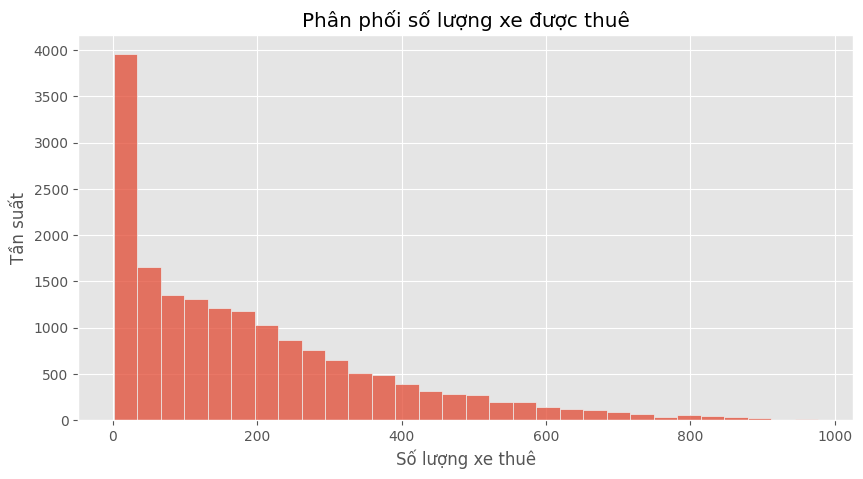

In [ ]:
plt.figure(figsize=(10,5))
sns.histplot(df1["cnt"], bins=30, kde=True)
plt.title("Histogram phân phối số lượng xe được thuê (cnt)")
plt.xlabel("Số lượng xe thuê")
plt.ylabel("Tần suất")
plt.show()

- Mục tiêu
    - Xem:dữ liệu lệch phải/trái| có peak không| phân phối ra sao.

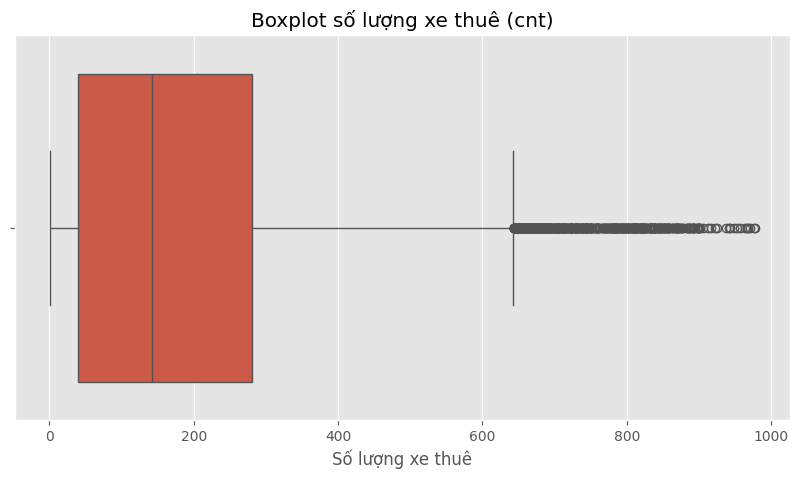

In [81]:
plt.figure(figsize=(10,5))
sns.boxplot(x=df1["cnt"])
plt.title("Boxplot số lượng xe thuê (cnt)")
plt.xlabel("Số lượng xe thuê")
plt.show()

### Noise | công thức IQR

In [171]:
Q1 = df1["cnt"].quantile(0.25)
Q3 = df1["cnt"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df1[
    (df1["cnt"] < lower_bound) |
    (df1["cnt"] > upper_bound)
]

print("Số lượng outlier:", outliers.shape[0])

Số lượng outlier: 505


Dataset có tồn tại outlier ở cột cnt.

Tuy nhiên nhóm quyết định giữ lại vì:
- đây là dữ liệu thực tế
- peak-hour là hành vi thật
- loại bỏ có thể làm mất business insight

Histogram / Boxplot cho numeric biến 'temp_combined'

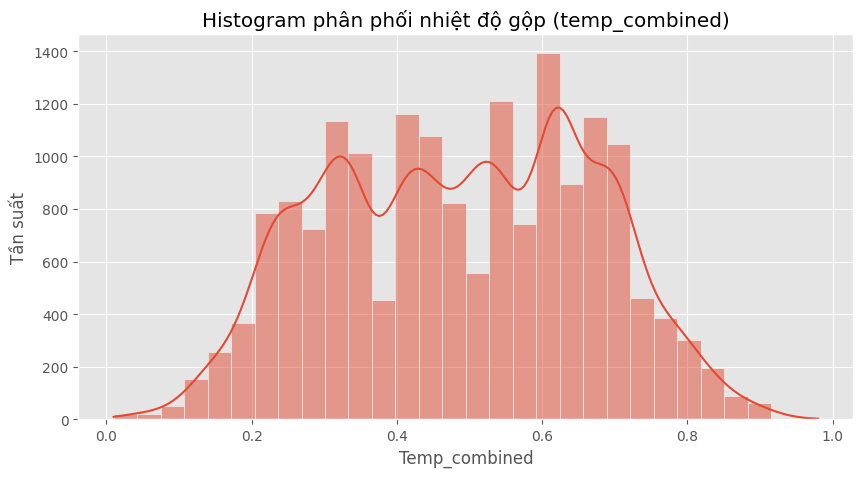

In [82]:
plt.figure(figsize=(10,5))
sns.histplot(df1["temp_combined"], bins=30, kde=True)
plt.title("Histogram phân phối nhiệt độ gộp (temp_combined)")
plt.xlabel("Temp_combined")
plt.ylabel("Tần suất")
plt.show()


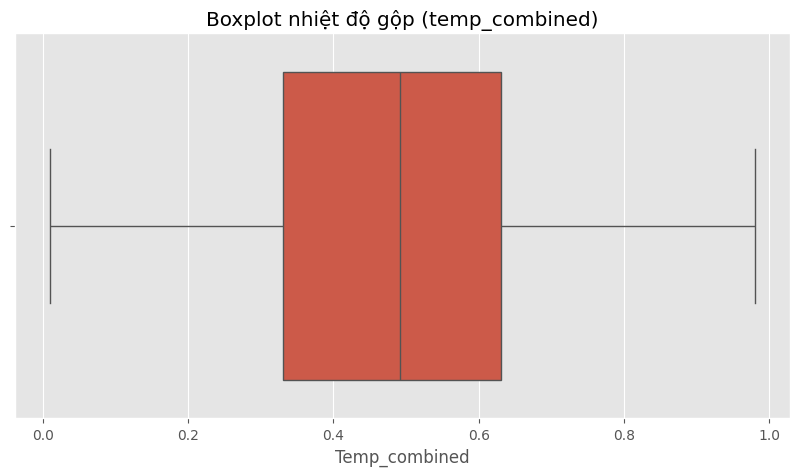

In [83]:
plt.figure(figsize=(10,5))
sns.boxplot(x=df1["temp_combined"])
plt.title("Boxplot nhiệt độ gộp (temp_combined)")
plt.xlabel("Temp_combined")
plt.show()

Histogram / Boxplot cho numeric biến 'hum'

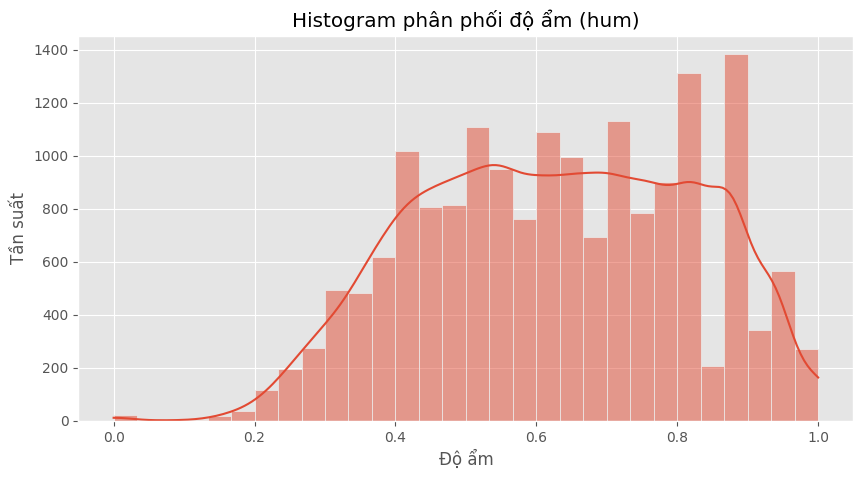

In [84]:
plt.figure(figsize=(10,5))
sns.histplot(df1["hum"], bins=30, kde=True)
plt.title("Histogram phân phối độ ẩm (hum)")
plt.xlabel("Độ ẩm")
plt.ylabel("Tần suất")
plt.show()

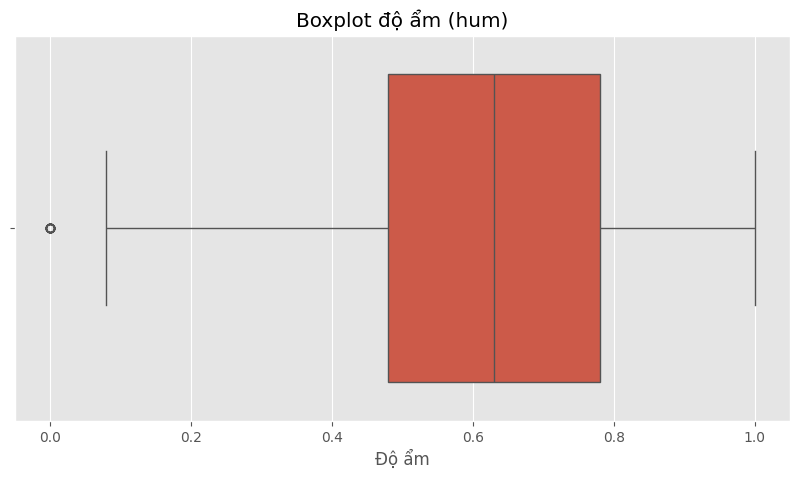

In [85]:
plt.figure(figsize=(10,5))
sns.boxplot(x=df1["hum"])
plt.title("Boxplot độ ẩm (hum)")
plt.xlabel("Độ ẩm")
plt.show()

Histogram / Boxplot cho numeric biến 'windspeed'

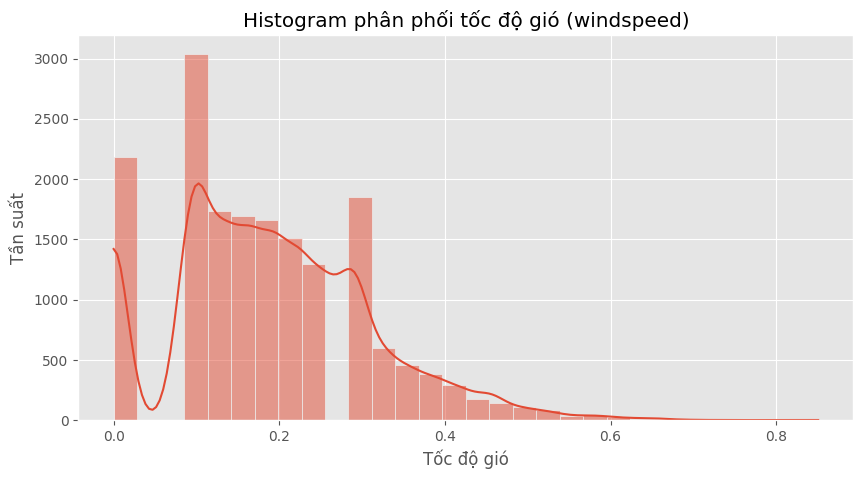

In [86]:
plt.figure(figsize=(10,5))
sns.histplot(df1["windspeed"], bins=30, kde=True)
plt.title("Histogram phân phối tốc độ gió (windspeed)")
plt.xlabel("Tốc độ gió")
plt.ylabel("Tần suất")
plt.show()

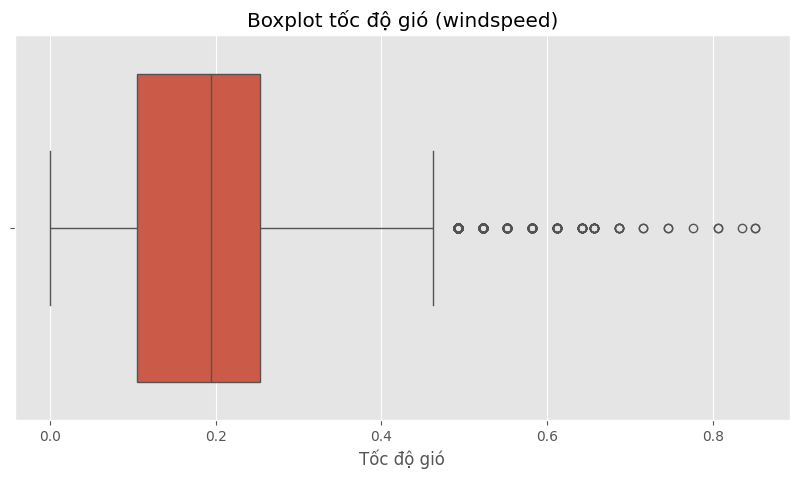

In [87]:
plt.figure(figsize=(10,5))
sns.boxplot(x=df1["windspeed"])
plt.title("Boxplot tốc độ gió (windspeed)")
plt.xlabel("Tốc độ gió")
plt.show()

Countplot cho categorical biến 'season'

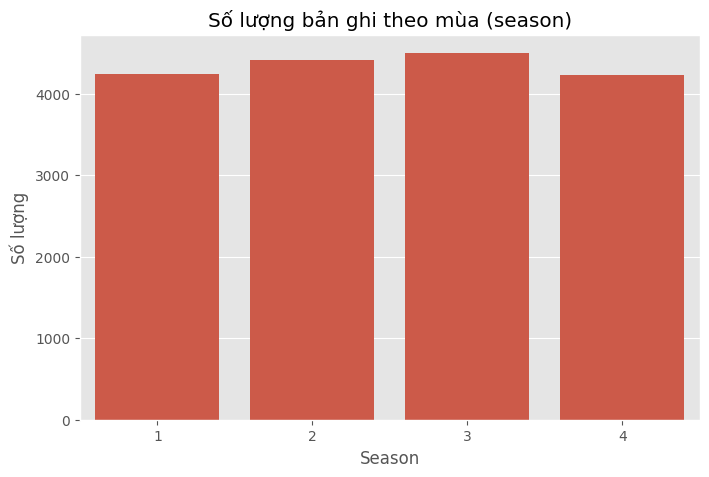

In [88]:
plt.figure(figsize=(8,5))
sns.countplot(data=df1, x="season")
plt.title("Số lượng bản ghi theo mùa (season)")
plt.xlabel("Season")
plt.ylabel("Số lượng")
plt.show()

Countplot cho categorical biến 'weathersit'

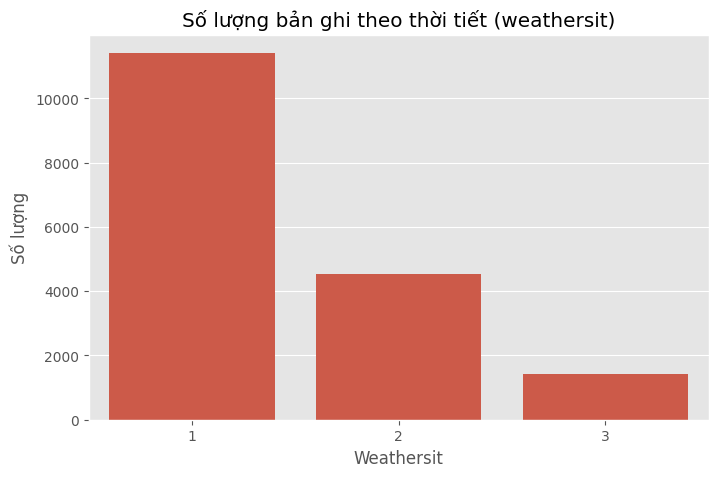

In [89]:
plt.figure(figsize=(8,5))
sns.countplot(data=df1, x="weathersit")
plt.title("Số lượng bản ghi theo thời tiết (weathersit)")
plt.xlabel("Weathersit")
plt.ylabel("Số lượng")
plt.show()

Countplot cho categorical biến 'workingday'

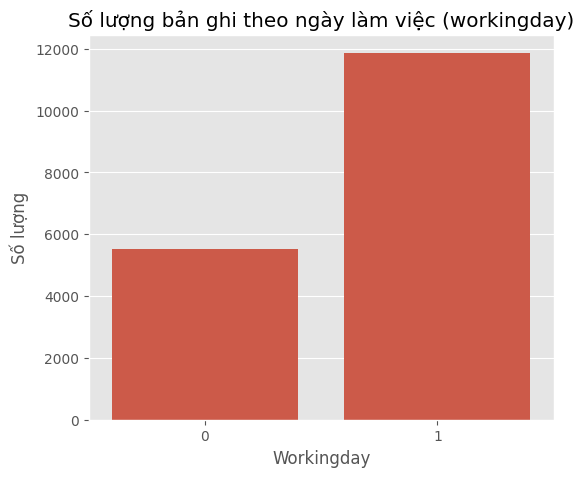

In [90]:
plt.figure(figsize=(6,5))
sns.countplot(data=df1, x="workingday")
plt.title("Số lượng bản ghi theo ngày làm việc (workingday)")
plt.xlabel("Workingday")
plt.ylabel("Số lượng")
plt.show()

### Biểu đồ lineplot / scatter / barplot cho 2 biến (bi-variable).

### HR VS CNT

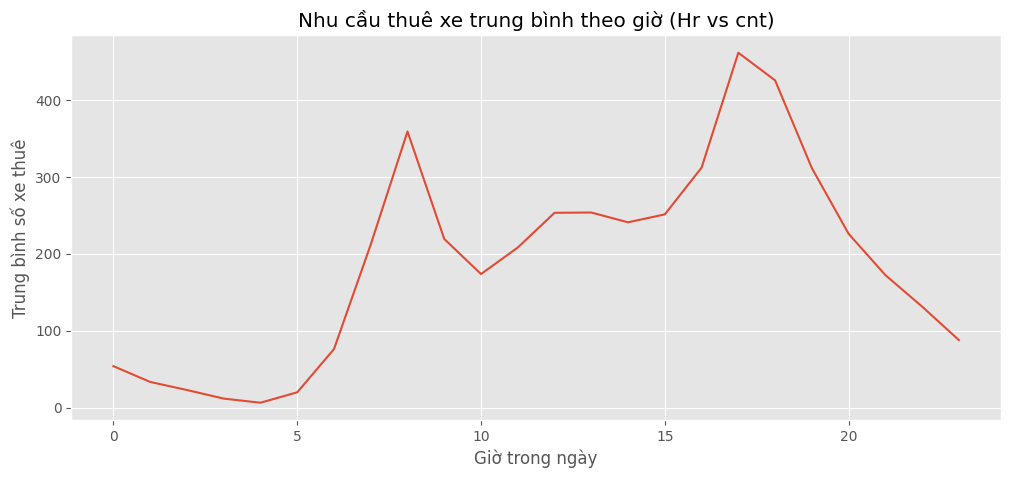

In [91]:
plt.figure(figsize=(12,5))
sns.lineplot(data=df1.groupby('hr')['cnt'].mean().reset_index(), x='hr', y='cnt')
plt.title("Nhu cầu thuê xe trung bình theo giờ (Hr vs cnt)")
plt.xlabel("Giờ trong ngày")
plt.ylabel("Trung bình số xe thuê")
plt.show()

Nhu cầu thuê xe đạt đỉnh vào:
- 7h–9h sáng
- 17h–19h chiều

Đây là thời gian đi làm và tan ca.

WEATHER VS CNT

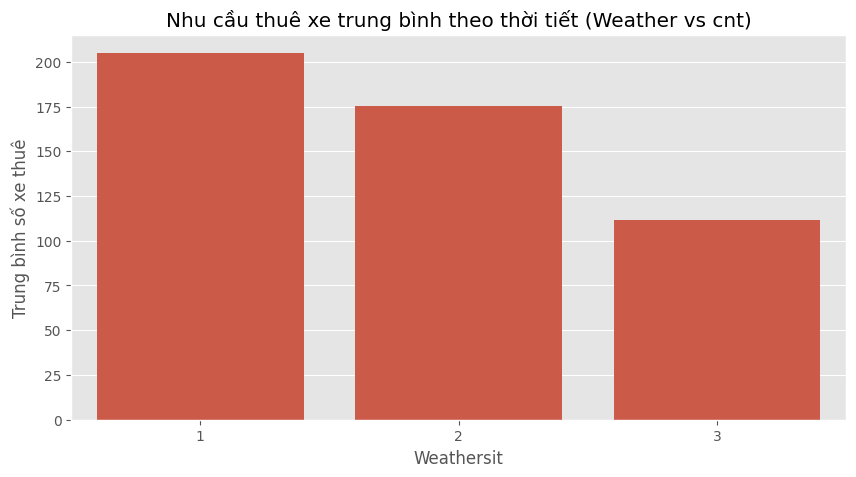

In [92]:
plt.figure(figsize=(10,5))
sns.barplot(data=df1.groupby('weathersit')['cnt'].mean().reset_index(), x='weathersit', y='cnt')
plt.title("Nhu cầu thuê xe trung bình theo thời tiết (Weather vs cnt)")
plt.xlabel("Weathersit")
plt.ylabel("Trung bình số xe thuê")
plt.show()

Thời tiết xấu làm giảm mạnh số lượng thuê xe.

### SEASON VS CNT

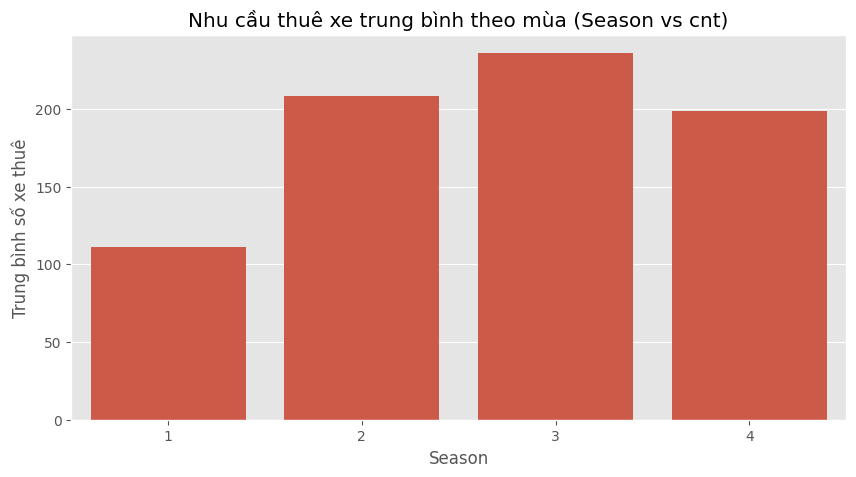

In [93]:
plt.figure(figsize=(10,5))
sns.barplot(data=df1.groupby('season')['cnt'].mean().reset_index(), x='season', y='cnt')
plt.title("Nhu cầu thuê xe trung bình theo mùa (Season vs cnt)")
plt.xlabel("Season")
plt.ylabel("Trung bình số xe thuê")
plt.show()

### WORKINGDAY VS CNT

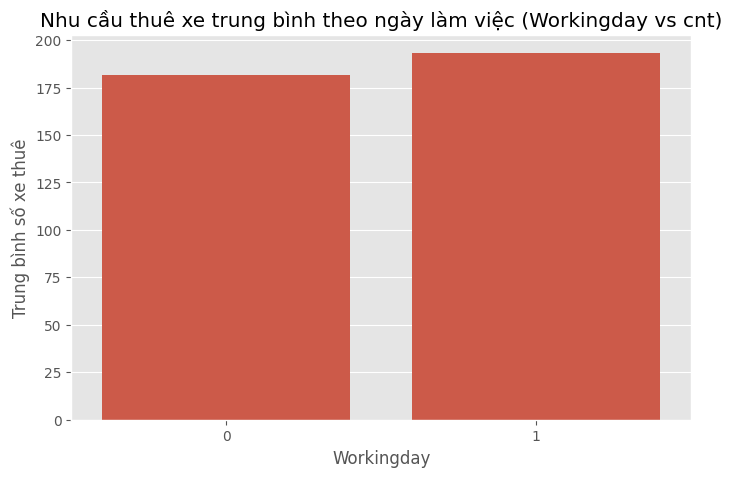

In [94]:
plt.figure(figsize=(8,5))
sns.barplot(data=df1.groupby('workingday')['cnt'].mean().reset_index(), x='workingday', y='cnt')
plt.title("Nhu cầu thuê xe trung bình theo ngày làm việc (Workingday vs cnt)")
plt.xlabel("Workingday")
plt.ylabel("Trung bình số xe thuê")
plt.show()

### Biểu đồ pairplot / heatmap / kết hợp nhiều biến (multi-variable)

### CORRELATION HEATMAP

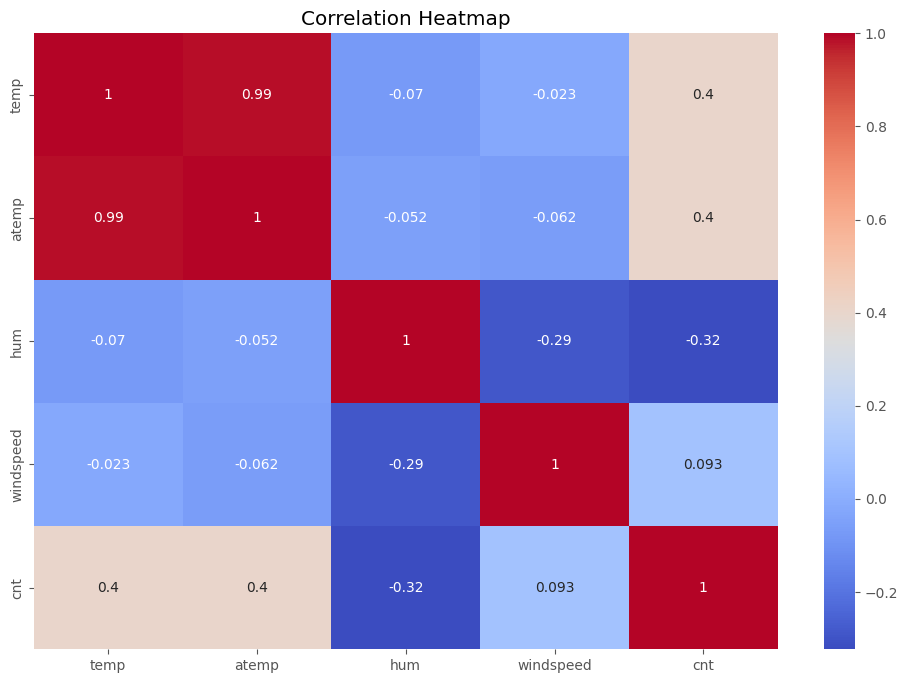

In [177]:
plt.figure(figsize=(12,8))

numeric_df = df1.select_dtypes(include=["int64", "float64"])

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.show()

Mục tiêu

Xem:

feature nào liên quan mạnh tới cnt.

### multivariable analysis.

Hr vs cnt theo mùa (lineplot với hue)

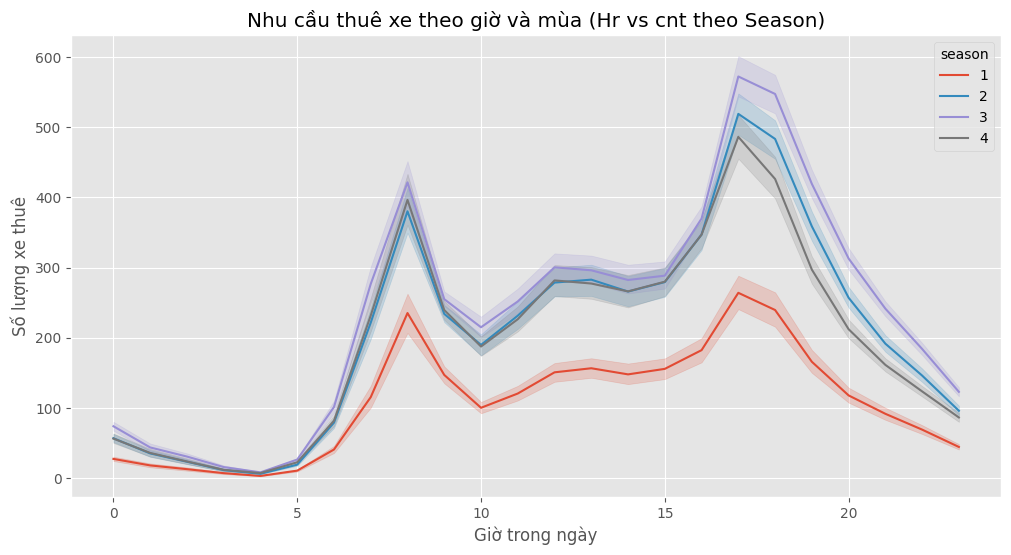

In [95]:
plt.figure(figsize=(12,6))
sns.lineplot(data=df1, x='hr', y='cnt', hue='season')
plt.title("Nhu cầu thuê xe theo giờ và mùa (Hr vs cnt theo Season)")
plt.xlabel("Giờ trong ngày")
plt.ylabel("Số lượng xe thuê")
plt.show()

Weather vs cnt theo workingday (boxplot)

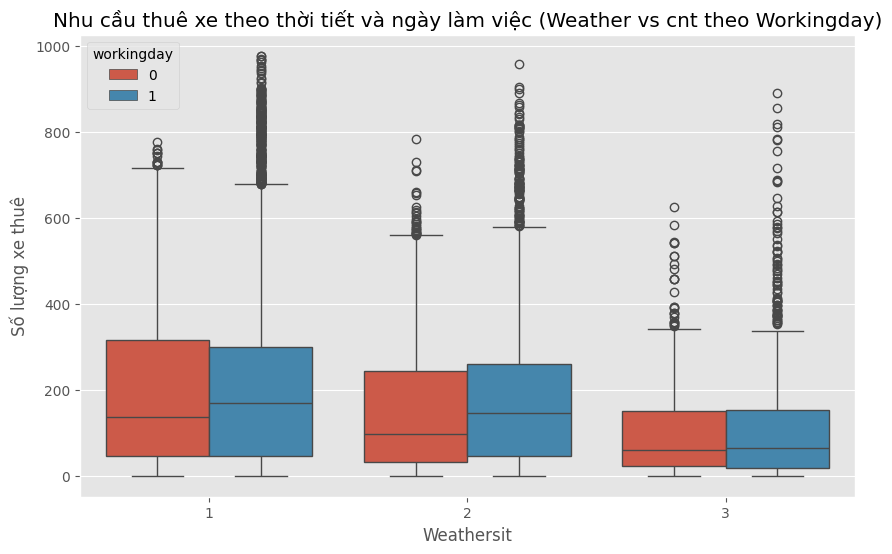

In [96]:
plt.figure(figsize=(10,6))
sns.boxplot(data=df1, x='weathersit', y='cnt', hue='workingday')
plt.title("Nhu cầu thuê xe theo thời tiết và ngày làm việc (Weather vs cnt theo Workingday)")
plt.xlabel("Weathersit")
plt.ylabel("Số lượng xe thuê")
plt.show()

Hr vs cnt theo workingday (lineplot với hue)

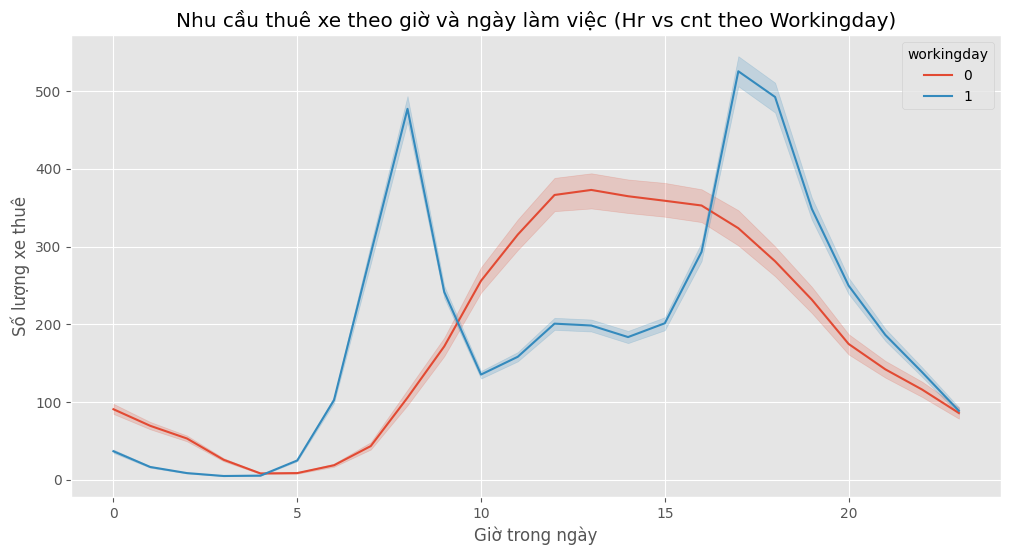

In [97]:
plt.figure(figsize=(12,6))
sns.lineplot(data=df1, x='hr', y='cnt', hue='workingday')
plt.title("Nhu cầu thuê xe theo giờ và ngày làm việc (Hr vs cnt theo Workingday)")
plt.xlabel("Giờ trong ngày")
plt.ylabel("Số lượng xe thuê")
plt.show()

# Business Insight

- Giờ trong ngày là yếu tố ảnh hưởng mạnh nhất tới nhu cầu thuê xe.
- Nhu cầu thuê xe cao vào giờ đi làm và tan ca.
- Thời tiết xấu làm giảm đáng kể số lượng thuê xe.
- Nhiệt độ dễ chịu giúp tăng nhu cầu thuê xe.
- Mùa hè và mùa thu có lượng thuê xe cao hơn.

# Prepare dataset cho ML

### One hot encoding

In [180]:
df_encoded = pd.get_dummies(
    df1,
    columns=categorical_cols,
    drop_first=True
)

In [181]:
df_encoded.head()

,temp,atemp,hum,windspeed,cnt,season_2,season_3,season_4,hr_1,hr_2,...,holiday_1,weekday_1,weekday_2,weekday_3,weekday_4,weekday_5,weekday_6,workingday_1,weathersit_2,weathersit_3
0,0.24,0.2879,0.81,0.0,16,False,False,False,False,False,...,False,False,False,False,False,False,True,False,False,False
1,0.22,0.2727,0.80,0.0,40,False,False,False,True,False,...,False,False,False,False,False,False,True,False,False,False
2,0.22,0.2727,0.80,0.0,32,False,False,False,False,True,...,False,False,False,False,False,False,True,False,False,False
3,0.24,0.2879,0.75,0.0,13,False,False,False,False,False,...,False,False,False,False,False,False,True,False,False,False
4,0.24,0.2879,0.75,0.0,1,False,False,False,False,False,...,False,False,False,False,False,False,True,False,False,False


In [182]:
df_encoded.shape

(17379, 41)

### CHIA X VÀ y

In [183]:
X = df_encoded.drop("cnt", axis=1)
y = df_encoded["cnt"]
print(X.shape)
print(y.shape)

(17379, 40)
(17379,)


### TRAIN TEST SPLIT

In [184]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [185]:
print(X_train.shape)
print(X_test.shape)

(13903, 40)
(3476, 40)


### Feature scaling

Các biến liên tục như temp, atemp, hum và windspeed trong dataset đã được chuẩn hóa sẵn về khoảng [0,1], do đó nhóm không thực hiện thêm bước feature scaling.

### TRAIN MODEL ĐẦU TIÊN

Linear Regression

In [186]:
from sklearn.linear_model import LinearRegression

lr_model = LinearRegression()

lr_model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [187]:
y_pred_lr = lr_model.predict(X_test)

In [188]:
import joblib

joblib.dump(
    lr_model,
    "../models/linear_regression.pkl"
)

['../models/linear_regression.pkl']

### EVALUATION

In [189]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)
mae = mean_absolute_error(y_test, y_pred_lr)
print("MAE:", mae)

rmse = np.sqrt(
    mean_squared_error(y_test, y_pred_lr)
)
print("RMSE:", rmse)

r2 = r2_score(y_test, y_pred_lr)

print("R2 Score:", r2)

MAE: 77.95829023253297
RMSE: 109.16392977073507
R2 Score: 0.6236662320166964


### RANDOM FOREST

In [190]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

In [191]:
rf_model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [192]:
y_pred_rf = rf_model.predict(X_test)

### Evaluate

In [193]:
mae_rf = mean_absolute_error(y_test, y_pred_rf)

rmse_rf = np.sqrt(
    mean_squared_error(y_test, y_pred_rf)
)

r2_rf = r2_score(y_test, y_pred_rf)

print("MAE :", mae_rf)
print("RMSE:", rmse_rf)
print("R2  :", r2_rf)

MAE : 49.63901815167954
RMSE: 74.97829579416032
R2  : 0.8224641776964943


### SO SÁNH MODEL

In [194]:
results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Random Forest"
    ],
    
    "MAE": [
        mae,
        mae_rf
    ],
    
    "RMSE": [
        rmse,
        rmse_rf
    ],
    
    "R2 Score": [
        r2,
        r2_rf
    ]
})

results

,Model,MAE,RMSE,R2 Score
0,Linear Regression,77.958290,109.163930,0.623666
1,Random Forest,49.639018,74.978296,0.822464


### FEATURE IMPORTANCE

In [195]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

In [196]:
importance = importance.sort_values(
    by="Importance",
    ascending=False
)

In [197]:
importance.head(10)

,Feature,Importance
1,atemp,0.170243
2,hum,0.104381
37,workingday_1,0.098573
23,hr_17,0.093121
24,hr_18,0.074234
0,temp,0.073656
14,hr_8,0.059303
3,windspeed,0.037582
25,hr_19,0.031107
6,season_4,0.018850


### Visualization

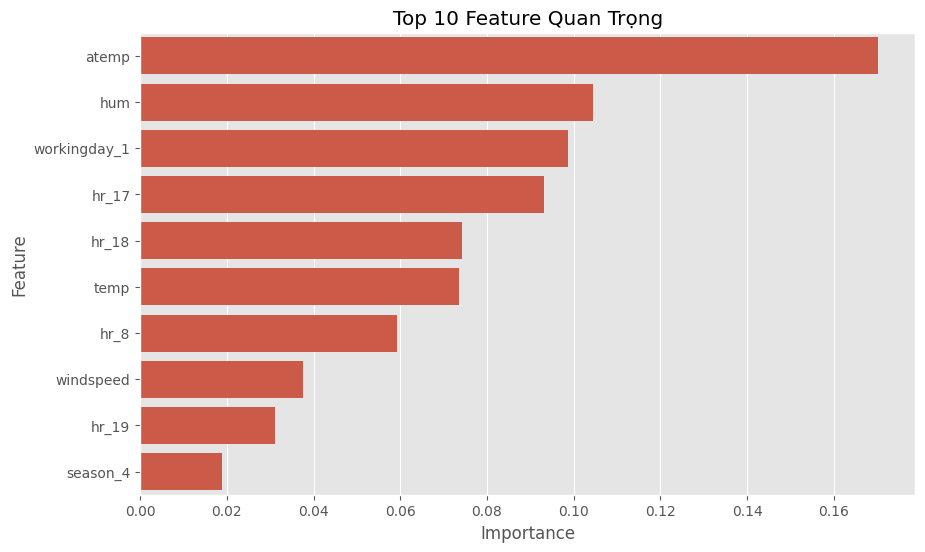

In [198]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=importance.head(10),
    x="Importance",
    y="Feature"
)

plt.title("Top 10 Feature Quan Trọng")

plt.show()

### SAVE MODEL

In [199]:
import joblib

joblib.dump(
    rf_model,
    "../models/random_forest.pkl"
)

['../models/random_forest.pkl']

# FINAL CONCLUSION

- Random Forest cho kết quả tốt hơn Linear Regression.
- Giờ trong ngày là feature quan trọng nhất.
- Thời tiết và nhiệt độ ảnh hưởng mạnh đến nhu cầu thuê xe.
- Hệ thống có thể hỗ trợ doanh nghiệp dự đoán nhu cầu thuê xe hiệu quả